<a href="https://colab.research.google.com/github/kuxx12257/machine_learnng_COOKBOOK/blob/branch1/co2emission_pnmregr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import pylab as pl
import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures

In [67]:
!wget -O FuelConsumption.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv

--2026-02-05 16:12:15--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 72629 (71K) [text/csv]
Saving to: ‘FuelConsumption.csv’

FuelConsumption.csv 100%[===================>]  70.93K  --.-KB/s    in 0.003s  

2026-02-05 16:12:15 (22.2 MB/s) - ‘FuelConsumption.csv’ saved [72629/72629]



In [68]:
df=pd.read_csv("FuelConsumption.csv")
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [69]:
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


In [70]:
cdf=df[["CYLINDERS","FUELCONSUMPTION_COMB","CO2EMISSIONS","ENGINESIZE"]]

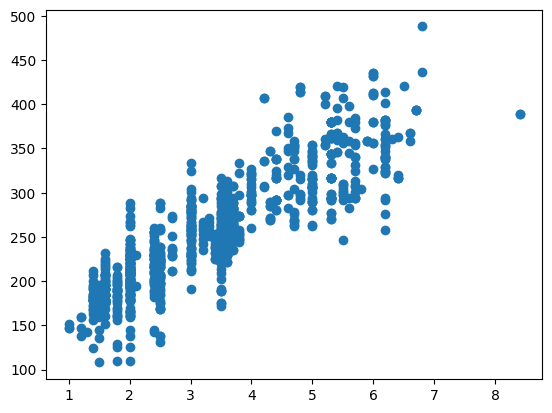

In [71]:
plt.scatter(cdf.ENGINESIZE,cdf.CO2EMISSIONS)
plt.show()

In [72]:
msk=np.random.rand(len(df))<0.80
train=cdf[msk]
test=cdf[~msk]
print(train)
print(test)

      CYLINDERS  FUELCONSUMPTION_COMB  CO2EMISSIONS  ENGINESIZE
1             4                   9.6           221         2.4
2             4                   5.9           136         1.5
3             6                  11.1           255         3.5
5             6                  10.0           230         3.5
7             6                  11.1           255         3.7
...         ...                   ...           ...         ...
1061          6                  11.2           258         3.2
1062          6                  11.8           271         3.0
1064          6                  11.8           271         3.0
1065          6                  11.3           260         3.2
1066          6                  12.8           294         3.2

[853 rows x 4 columns]
      CYLINDERS  FUELCONSUMPTION_COMB  CO2EMISSIONS  ENGINESIZE
0             4                   8.5           196         2.0
4             6                  10.6           244         3.5
6             6 

In [73]:
train_x=np.asanyarray(train[['ENGINESIZE']])
train_y=np.asanyarray(train[["CO2EMISSIONS"]])

poly=PolynomialFeatures(degree=2)

train_x_poly=poly.fit_transform(train_x)
print(train_x_poly)

[[ 1.    2.4   5.76]
 [ 1.    1.5   2.25]
 [ 1.    3.5  12.25]
 ...
 [ 1.    3.    9.  ]
 [ 1.    3.2  10.24]
 [ 1.    3.2  10.24]]


In [74]:
from sklearn import linear_model
regr=linear_model.LinearRegression()
regr.fit(train_x_poly,train_y)

print("coefficient:",regr.coef_)
print("intercept:",regr.intercept_)

coefficient: [[ 0.         50.357971   -1.48712492]]
intercept: [107.49540292]


In [75]:
#testing set
test_x=np.asanyarray(test[["ENGINESIZE"]])
test_y=np.asanyarray(test[["CO2EMISSIONS"]])

poly=PolynomialFeatures(degree=2)

test_x_poly=poly.fit_transform(test_x)

test_Y=regr.predict(test_x_poly)

In [76]:
print("the accuracy of evaluation:",r2_score(test_Y,test_y))

the accuracy of evaluation: 0.6753942240671003


Text(0, 0.5, 'Emission')

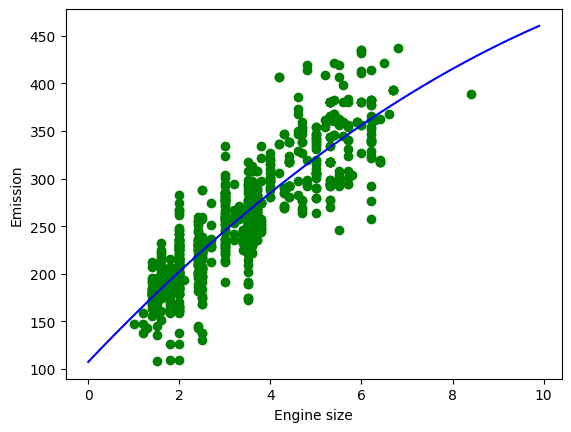

In [77]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS,  color='green')
XX = np.arange(0.0, 10.0, 0.1)
yy = regr.intercept_[0]+ regr.coef_[0][1]*XX+ regr.coef_[0][2]*np.power(XX, 2)
plt.plot(XX, yy, 'b' )
plt.xlabel("Engine size")
plt.ylabel("Emission")